# 03. LSTM Autoencoder — 수도권 아파트 버블 이상 탐지

- **입력**: `data/processed/features_sido_monthly.csv` (468행 × 42컬럼)
- **방법**: 정상(label=0) 시퀀스만 학습 → 전체 재구성 오차로 이상 탐지
- **피처**: 16개 (가격 변화율, 전세가율, PIR, 금리, 거시, 공급, 레버리지)
- **구조**: LSTM Encoder → Latent → LSTM Decoder (seq_len=12)
- **HPO**: Optuna 30 trials
- **출력**:
  - `data/processed/lstm_ae_scores.csv` — 월별 재구성 오차 + 이상 여부
  - `models/lstm_ae_best.pth` — 최적 모델 가중치

In [1]:
import sys, os, warnings, random
warnings.filterwarnings('ignore')
os.chdir('c:/Users/bko05/Desktop/seoul-bubble-detection')
os.makedirs('models', exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 재현성 고정
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cpu')
ENC    = 'utf-8-sig'
plt.rcParams['font.family']       = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi']         = 110

print(f'torch  : {torch.__version__}')
print(f'optuna : {optuna.__version__}')
print(f'device : {DEVICE}')

torch  : 2.11.0+cpu
optuna : 4.8.0
device : cpu


---
## 1. 데이터 준비 & 피처 선택

In [2]:
df = pd.read_csv('data/processed/features_sido_monthly.csv', encoding=ENC)
df['ym_dt'] = pd.to_datetime(df['ym'].astype(str), format='%Y%m')

# ── 16개 피처 선택 (레벨 지표 제외, 검색트렌드 제외 — 2013~2015 zero-fill)
FEATURES = [
    '매매중위_MoM',          # 가격 전월 변화율 (%)
    '매매중위_YoY',          # 가격 전년 변화율 (%)
    '매매_vol12',            # 가격 12개월 변동성
    '전세가율',              # 전세가율 (%)
    'PIR',                  # 가격/소득 배수
    '소득대비전세율',         # 전세가/소득 배수
    'base_rate',            # 기준금리 (%)
    'rate_spread',          # 주담대-기준금리 스프레드
    'mortgage_rate_chg_yoy',# 주담대금리 전년 변화 (pp)
    'm2_yoy_pct',           # M2 통화량 전년 증가율 (%)
    'cpi_yoy_pct',          # 소비자물가 전년 상승률 (%)
    'bsi_realestate',       # 부동산업 BSI
    '미분양_yoy',            # 공사완료후 미분양 전년 변화율 (%)
    '인허가_yoy',            # 주택 인허가 rolling-12 전년 변화율 (%)
    '차주당대출_yoy',         # 차주당 대출 전년 변화율 (%)
    '가계대출비중_yoy',       # 가계대출 비중 전년 변화 (pp)
]

# ── NaN 확인 (첫 12개월 YoY = 정상 결측)
print(f'전체 행: {len(df)}')
print(f'피처별 결측 (NaN 행수):')
print(df[FEATURES].isnull().sum().to_string())

# ── 결측 처리: YoY 0으로 채우기 (초기 12개월, 의미 있는 변화 없음)
df_filled = df.copy()
df_filled[FEATURES] = df_filled[FEATURES].fillna(0)

print(f'\n결측 처리 후 NaN: {df_filled[FEATURES].isnull().sum().sum()}개')

전체 행: 468
피처별 결측 (NaN 행수):
매매중위_MoM                  3
매매중위_YoY                 36
매매_vol12                 36
전세가율                      0
PIR                       0
소득대비전세율                   0
base_rate                 0
rate_spread               0
mortgage_rate_chg_yoy    36
m2_yoy_pct               36
cpi_yoy_pct              36
bsi_realestate            0
미분양_yoy                  36
인허가_yoy                  69
차주당대출_yoy                36
가계대출비중_yoy               36

결측 처리 후 NaN: 0개


---
## 2. 시도별 MinMaxScaler (정상 데이터로 fit)

In [3]:
SIDO_LIST = ['서울', '경기', '인천']

# ── 시도별 스케일러: 정상(label=0) 데이터로만 fit (데이터 누출 방지)
scalers = {}
df_scaled_list = []

for sido in SIDO_LIST:
    sub = df_filled[df_filled['시도'] == sido].sort_values('ym').reset_index(drop=True)

    # 정상 행만으로 스케일러 학습
    normal_mask = sub['bubble_label'] == 0
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaler.fit(sub.loc[normal_mask, FEATURES])
    scalers[sido] = scaler

    # 전체 데이터 변환
    scaled_vals = scaler.transform(sub[FEATURES])
    sub_scaled  = sub.copy()
    sub_scaled[FEATURES] = scaled_vals
    df_scaled_list.append(sub_scaled)
    print(f'{sido}: 정상 {normal_mask.sum()}행으로 fit | 전체 {len(sub)}행 transform')

df_scaled = pd.concat(df_scaled_list, ignore_index=True)
print(f'\n정규화 완료: {df_scaled.shape}')

서울: 정상 93행으로 fit | 전체 156행 transform
경기: 정상 135행으로 fit | 전체 156행 transform
인천: 정상 143행으로 fit | 전체 156행 transform

정규화 완료: (468, 43)


---
## 3. 시퀀스 데이터셋 구성

In [4]:
SEQ_LEN   = 12   # 12개월 슬라이딩 윈도우 (Optuna에서 추가 튜닝 가능)
N_FEATURES = len(FEATURES)

def make_sequences(data_df: pd.DataFrame, seq_len: int, normal_only: bool = True):
    """
    시도별 시계열에서 슬라이딩 윈도우 시퀀스 추출.
    normal_only=True: 윈도우 내 모든 스텝이 label=0인 시퀀스만 반환 (학습용)
    normal_only=False: 모든 시퀀스 반환 (추론용)
    반환: (sequences, labels, end_ym) 각각 numpy array
    """
    seqs, labels, end_yms, start_idxs = [], [], [], []

    for sido in SIDO_LIST:
        sub = data_df[data_df['시도'] == sido].sort_values('ym').reset_index(drop=True)
        vals   = sub[FEATURES].values.astype(np.float32)   # (T, F)
        lbls   = sub['bubble_label'].values                  # (T,)
        yms    = sub['ym'].values                            # (T,)

        for i in range(len(sub) - seq_len + 1):
            window_lbls = lbls[i: i + seq_len]
            if normal_only and not np.all(window_lbls == 0):
                continue
            seqs.append(vals[i: i + seq_len])
            labels.append(lbls[i + seq_len - 1])  # 마지막 스텝의 레이블
            end_yms.append(yms[i + seq_len - 1])  # 마지막 스텝의 연월
            start_idxs.append(i)

    return (np.array(seqs),
            np.array(labels),
            np.array(end_yms))

# 학습용: 정상 시퀀스만
train_seqs, train_labels, train_yms = make_sequences(df_scaled, SEQ_LEN, normal_only=True)
# 추론용: 모든 시퀀스
all_seqs,   all_labels,   all_yms   = make_sequences(df_scaled, SEQ_LEN, normal_only=False)

print(f'학습용 시퀀스 (정상만): {train_seqs.shape}')
print(f'추론용 시퀀스 (전체):   {all_seqs.shape}')
print(f'학습 레이블 분포: {dict(zip(*np.unique(train_labels, return_counts=True)))}')


class SeqDataset(Dataset):
    def __init__(self, seqs):
        self.seqs = torch.tensor(seqs, dtype=torch.float32)
    def __len__(self):  return len(self.seqs)
    def __getitem__(self, i): return self.seqs[i]

train_ds = SeqDataset(train_seqs)
all_ds   = SeqDataset(all_seqs)
print(f'\nDataset 생성 완료')

학습용 시퀀스 (정상만): (263, 12, 16)
추론용 시퀀스 (전체):   (435, 12, 16)


학습 레이블 분포: {np.float64(0.0): np.int64(263)}

Dataset 생성 완료


---
## 4. LSTM Autoencoder 모델 정의

In [5]:
class LSTMAutoEncoder(nn.Module):
    """
    LSTM 기반 Autoencoder
    ┌─────────────────────────────────────────────────────────┐
    │  Encoder                                                 │
    │  (B, T, F) ─LSTM─► (B, T, H) ─last_hidden─► (B, H)    │
    │             ─Linear─► latent z (B, L)                   │
    │  Decoder                                                 │
    │  z (B, L) ─Linear─► (B, H) ─repeat T─► (B, T, H)      │
    │             ─LSTM─► (B, T, H) ─Linear─► (B, T, F)      │
    └─────────────────────────────────────────────────────────┘
    """
    def __init__(self, n_features: int, hidden_size: int,
                 latent_dim: int, num_layers: int, dropout: float):
        super().__init__()
        dp = dropout if num_layers > 1 else 0.0

        # Encoder
        self.enc_lstm = nn.LSTM(n_features, hidden_size, num_layers,
                                batch_first=True, dropout=dp)
        self.enc_fc   = nn.Linear(hidden_size, latent_dim)

        # Decoder
        self.dec_fc   = nn.Linear(latent_dim, hidden_size)
        self.dec_lstm = nn.LSTM(hidden_size, hidden_size, num_layers,
                                batch_first=True, dropout=dp)
        self.out_fc   = nn.Linear(hidden_size, n_features)

    def encode(self, x):
        _, (h, _) = self.enc_lstm(x)   # h: (num_layers, B, H)
        z = self.enc_fc(h[-1])          # (B, L)
        return z

    def decode(self, z, seq_len):
        d = self.dec_fc(z).unsqueeze(1).repeat(1, seq_len, 1)  # (B, T, H)
        out, _ = self.dec_lstm(d)                               # (B, T, H)
        return self.out_fc(out)                                  # (B, T, F)

    def forward(self, x):
        z    = self.encode(x)
        recon = self.decode(z, x.size(1))
        return recon, z


def reconstruction_loss(recon, x):
    """배치 평균 MSE (피처 × 시간 스텝 평균)"""
    return nn.functional.mse_loss(recon, x)


# 모델 구조 미리보기
demo = LSTMAutoEncoder(N_FEATURES, hidden_size=64, latent_dim=16, num_layers=2, dropout=0.1)
demo_in  = torch.randn(8, SEQ_LEN, N_FEATURES)
demo_out, demo_z = demo(demo_in)
print(f'입력  shape : {demo_in.shape}')
print(f'출력  shape : {demo_out.shape}')
print(f'잠재 shape  : {demo_z.shape}')
total_params = sum(p.numel() for p in demo.parameters())
print(f'파라미터 수  : {total_params:,}')

입력  shape : torch.Size([8, 12, 16])
출력  shape : torch.Size([8, 12, 16])
잠재 shape  : torch.Size([8, 16])
파라미터 수  : 124,000


---
## 5. 학습 유틸리티 함수

In [6]:
def train_one_epoch(model, loader, optimizer):
    model.train()
    total = 0.0
    for x in loader:
        x = x.to(DEVICE)
        recon, _ = model(x)
        loss = reconstruction_loss(recon, x)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total += loss.item() * len(x)
    return total / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total = 0.0
    for x in loader:
        x = x.to(DEVICE)
        recon, _ = model(x)
        total += reconstruction_loss(recon, x).item() * len(x)
    return total / len(loader.dataset)


@torch.no_grad()
def get_recon_errors(model, loader):
    """각 샘플의 per-step MSE 벡터 반환 (B, T) → 평균 → (B,) scalar"""
    model.eval()
    errors = []
    for x in loader:
        x     = x.to(DEVICE)
        recon, _ = model(x)
        # MSE per sample: (B, T, F) → mean over F → (B, T) → mean over T → (B,)
        mse = ((recon - x) ** 2).mean(dim=-1).mean(dim=-1)
        errors.append(mse.cpu().numpy())
    return np.concatenate(errors)


def train_model(params: dict, train_ds: Dataset,
                n_epochs: int = 100, patience: int = 15,
                val_ratio: float = 0.15, verbose: bool = False):
    """학습 + Early Stopping. 최저 val_loss 모델 반환."""
    torch.manual_seed(SEED)

    n_val   = max(1, int(len(train_ds) * val_ratio))
    n_train = len(train_ds) - n_val
    tr_ds, vl_ds = random_split(train_ds, [n_train, n_val],
                                 generator=torch.Generator().manual_seed(SEED))

    tr_loader = DataLoader(tr_ds, batch_size=params['batch_size'], shuffle=True)
    vl_loader = DataLoader(vl_ds, batch_size=params['batch_size'])

    model = LSTMAutoEncoder(
        n_features  = N_FEATURES,
        hidden_size = params['hidden_size'],
        latent_dim  = params['latent_dim'],
        num_layers  = params['num_layers'],
        dropout     = params['dropout'],
    ).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5)

    best_val, best_state, wait = float('inf'), None, 0
    history = []

    for epoch in range(1, n_epochs + 1):
        tr_loss = train_one_epoch(model, tr_loader, optimizer)
        vl_loss = evaluate(model, vl_loader)
        scheduler.step(vl_loss)
        history.append((tr_loss, vl_loss))

        if vl_loss < best_val:
            best_val   = vl_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                if verbose: print(f'  Early stop @ epoch {epoch}')
                break

    model.load_state_dict(best_state)
    return model, best_val, history

print('유틸리티 함수 정의 완료')

유틸리티 함수 정의 완료

---
## 6. Optuna 하이퍼파라미터 튜닝 (30 trials)

In [7]:
def optuna_objective(trial):
    params = {
        'hidden_size': trial.suggest_categorical('hidden_size', [32, 64, 128]),
        'latent_dim':  trial.suggest_categorical('latent_dim',  [8, 16, 32]),
        'num_layers':  trial.suggest_int('num_layers', 1, 2),
        'dropout':     trial.suggest_float('dropout',  0.0, 0.3, step=0.1),
        'lr':          trial.suggest_float('lr', 5e-4, 5e-3, log=True),
        'batch_size':  trial.suggest_categorical('batch_size', [16, 32]),
    }
    # HPO 단계는 epoch 수를 줄여 빠르게 탐색
    _, val_loss, _ = train_model(params, train_ds, n_epochs=50, patience=8)
    return val_loss


print('Optuna HPO 시작 (15 trials) ...')
study = optuna.create_study(direction='minimize',
                             sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(optuna_objective, n_trials=15, show_progress_bar=False)

best_params = study.best_params
print(f'최적 val_loss : {study.best_value:.6f}')
print(f'최적 파라미터  : {best_params}')

# 상위 5개 trial 출력
trials_df = study.trials_dataframe().sort_values('value').head(5)
print(f'\nTop-5 trials:')
print(trials_df[['number','value','params_hidden_size','params_latent_dim','params_num_layers','params_lr']].to_string(index=False))

Optuna HPO 시작 (15 trials) ...


최적 val_loss : 0.005821
최적 파라미터  : {'hidden_size': 128, 'latent_dim': 32, 'num_layers': 1, 'dropout': 0.1, 'lr': 0.002847876440759923, 'batch_size': 16}

Top-5 trials:
 number    value  params_hidden_size  params_latent_dim  params_num_layers  params_lr
      9 0.005821                 128                 32                  1   0.002848
     14 0.006156                 128                 16                  1   0.002239
      2 0.007804                 128                  8                  2   0.002025
      0 0.007926                  64                  8                  1   0.001996
      7 0.008746                  64                  8                  1   0.001057


---
## 7. 최종 모델 학습 (Early Stopping, 200 epochs)

최종 모델 학습 중 ...


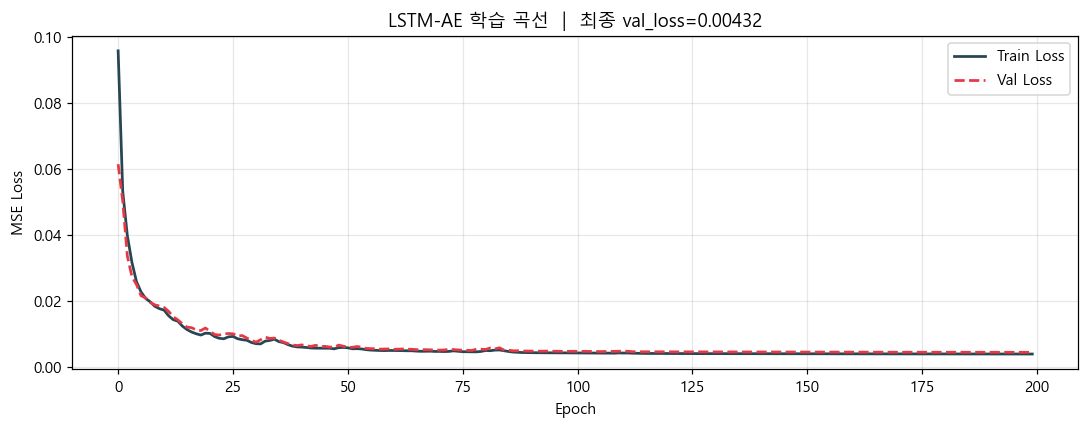

모델 저장: models/lstm_ae_best.pth


In [8]:
print('최종 모델 학습 중 ...')
final_model, final_val, history = train_model(
    best_params, train_ds,
    n_epochs=200, patience=20,
    val_ratio=0.15, verbose=True
)

# 학습 곡선 시각화
tr_losses = [h[0] for h in history]
vl_losses = [h[1] for h in history]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(tr_losses, label='Train Loss', color='#264653', lw=1.8)
ax.plot(vl_losses, label='Val Loss',   color='#E63946', lw=1.8, ls='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title(f'LSTM-AE 학습 곡선  |  최종 val_loss={final_val:.5f}', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('notebooks/fig_ae_01_training_curve.png', bbox_inches='tight')
plt.show()

# 모델 저장
torch.save({
    'model_state': final_model.state_dict(),
    'params':      best_params,
    'features':    FEATURES,
    'seq_len':     SEQ_LEN,
}, 'models/lstm_ae_best.pth')
print('모델 저장: models/lstm_ae_best.pth')

---
## 8. 재구성 오차 계산 & 임계값 설정

In [9]:
# ── 전체 시퀀스 재구성 오차 계산
all_loader  = DataLoader(all_ds, batch_size=64)
all_errors  = get_recon_errors(final_model, all_loader)

# 학습 시퀀스(정상) 오차 → 임계값 설정
train_loader = DataLoader(train_ds, batch_size=64)
train_errors = get_recon_errors(final_model, train_loader)

THRESHOLD_PCT = 95   # 95th percentile
threshold     = np.percentile(train_errors, THRESHOLD_PCT)

print(f'학습(정상) 재구성 오차 — 통계:')
print(f'  평균: {train_errors.mean():.5f}')
print(f'  std:  {train_errors.std():.5f}')
print(f'  95th: {np.percentile(train_errors, 95):.5f}')
print(f'  99th: {np.percentile(train_errors, 99):.5f}')
print(f'\n이상 탐지 임계값 ({THRESHOLD_PCT}th percentile): {threshold:.5f}')
print(f'전체 이상 탐지: {(all_errors > threshold).sum()} / {len(all_errors)} 시퀀스')

# ── 결과 데이터프레임 구성
# all_yms: 각 시퀀스의 마지막 스텝 연월 + 시도 정보 필요
# 시도 정보를 다시 추출
all_sidos = []
all_ym_list = []
all_label_list = []
for sido in SIDO_LIST:
    sub = df_scaled[df_scaled['시도'] == sido].sort_values('ym').reset_index(drop=True)
    lbls = sub['bubble_label'].values
    yms  = sub['ym'].values
    for i in range(len(sub) - SEQ_LEN + 1):
        all_sidos.append(sido)
        all_ym_list.append(yms[i + SEQ_LEN - 1])
        all_label_list.append(lbls[i + SEQ_LEN - 1])

result_df = pd.DataFrame({
    'ym':          all_ym_list,
    '시도':         all_sidos,
    'recon_error': all_errors,
    'bubble_label': all_label_list,
    'anomaly':     (all_errors > threshold).astype(int),
})
result_df['ym_dt'] = pd.to_datetime(result_df['ym'].astype(str), format='%Y%m')

print(f'\nresult_df shape: {result_df.shape}')
print(f'이상 감지 분포:')
print(result_df.groupby(['시도','anomaly']).size().unstack(fill_value=0))

학습(정상) 재구성 오차 — 통계:
  평균: 0.00387
  std:  0.00174
  95th: 0.00802
  99th: 0.01003

이상 탐지 임계값 (95th percentile): 0.00802
전체 이상 탐지: 179 / 435 시퀀스



result_df shape: (435, 6)
이상 감지 분포:
anomaly    0    1
시도               
경기       100   45
서울        45  100
인천       111   34


---
## 9. 재구성 오차 시각화

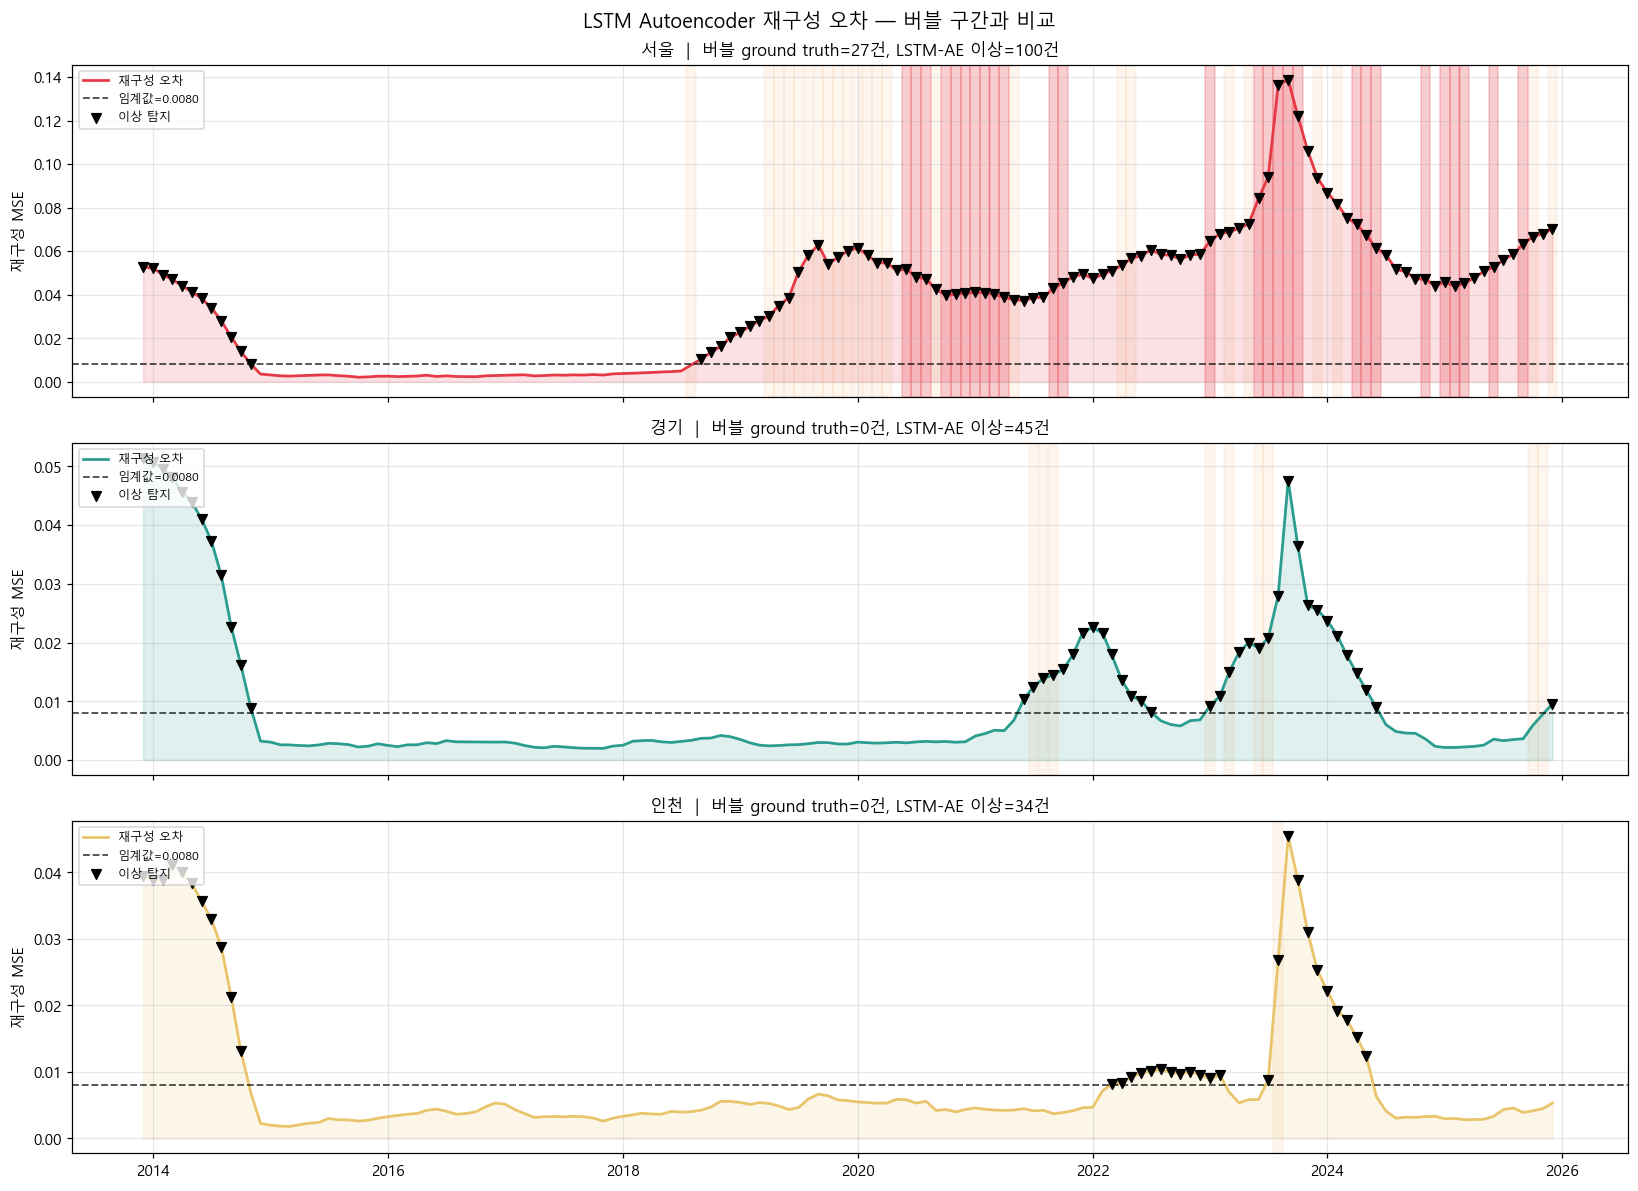

In [10]:
SIDO_COLORS = {'서울': '#E63946', '경기': '#2A9D8F', '인천': '#E9C46A'}

fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True)

for ax, sido in zip(axes, SIDO_LIST):
    sub = result_df[result_df['시도'] == sido].sort_values('ym_dt')
    c   = SIDO_COLORS[sido]

    # 재구성 오차 라인
    ax.plot(sub['ym_dt'], sub['recon_error'], color=c, lw=1.8, label='재구성 오차')
    ax.fill_between(sub['ym_dt'], sub['recon_error'], alpha=0.15, color=c)

    # 임계값 기준선
    ax.axhline(threshold, color='black', ls='--', lw=1.2, alpha=0.7, label=f'임계값={threshold:.4f}')

    # 버블 구간 하이라이트 (ground truth)
    for _, row in sub[sub['bubble_label'] == 2].iterrows():
        ax.axvspan(row['ym_dt'] - pd.Timedelta(days=15),
                   row['ym_dt'] + pd.Timedelta(days=15),
                   alpha=0.25, color='#E63946', zorder=0)
    for _, row in sub[sub['bubble_label'] == 1].iterrows():
        ax.axvspan(row['ym_dt'] - pd.Timedelta(days=15),
                   row['ym_dt'] + pd.Timedelta(days=15),
                   alpha=0.10, color='#F4A261', zorder=0)

    # 이상 감지 마커
    anomaly_sub = sub[sub['anomaly'] == 1]
    ax.scatter(anomaly_sub['ym_dt'], anomaly_sub['recon_error'],
               color='black', s=40, zorder=5, marker='v', label='이상 탐지')

    b_cnt = int(sub[sub['bubble_label']==2].shape[0])
    a_cnt = int(anomaly_sub.shape[0])
    ax.set_title(f'{sido}  |  버블 ground truth={b_cnt}건, LSTM-AE 이상={a_cnt}건', fontsize=11)
    ax.set_ylabel('재구성 MSE')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(alpha=0.3)

plt.suptitle('LSTM Autoencoder 재구성 오차 — 버블 구간과 비교', fontsize=13)
plt.tight_layout()
plt.savefig('notebooks/fig_ae_02_recon_error.png', bbox_inches='tight')
plt.show()

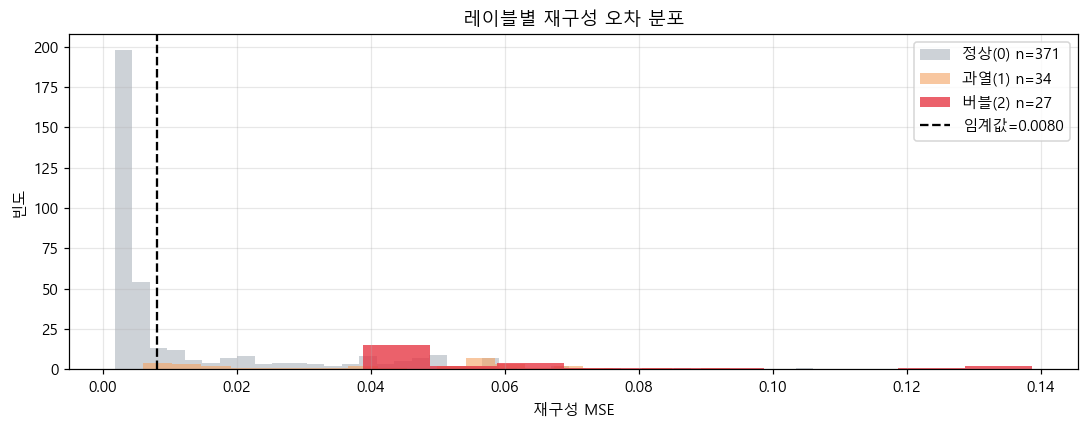

정상  오차 중위: 0.00419
과열  오차 중위: 0.05193
버블  오차 중위: 0.04712
임계값          : 0.00802


In [11]:
# ── 오차 분포 히스토그램 (정상 vs 버블)
valid_res = result_df[result_df['bubble_label'].notna()].copy()
normal_err = valid_res[valid_res['bubble_label'] == 0]['recon_error']
bubble_err = valid_res[valid_res['bubble_label'] == 2]['recon_error']
heat_err   = valid_res[valid_res['bubble_label'] == 1]['recon_error']

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(normal_err, bins=40, alpha=0.6, color='#ADB5BD', label=f'정상(0) n={len(normal_err)}')
ax.hist(heat_err,   bins=20, alpha=0.6, color='#F4A261', label=f'과열(1) n={len(heat_err)}')
ax.hist(bubble_err, bins=10, alpha=0.8, color='#E63946', label=f'버블(2) n={len(bubble_err)}')
ax.axvline(threshold, color='black', ls='--', lw=1.5, label=f'임계값={threshold:.4f}')
ax.set_xlabel('재구성 MSE')
ax.set_ylabel('빈도')
ax.set_title('레이블별 재구성 오차 분포', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('notebooks/fig_ae_03_error_dist.png', bbox_inches='tight')
plt.show()

print(f'정상  오차 중위: {normal_err.median():.5f}')
print(f'과열  오차 중위: {heat_err.median():.5f}')
print(f'버블  오차 중위: {bubble_err.median():.5f}')
print(f'임계값          : {threshold:.5f}')

---
## 10. 성능 평가 (bubble_label vs anomaly)

=== 버블(2) 탐지 성능 ===
              precision    recall  f1-score   support

         비버블      1.000     0.632     0.775       405
          버블      0.153     1.000     0.266        27

    accuracy                          0.655       432
   macro avg      0.577     0.816     0.520       432
weighted avg      0.947     0.655     0.743       432

AUC-ROC (재구성 오차 기반): 0.9105

=== 과열+버블(≥1) 탐지 성능 ===
              precision    recall  f1-score   support

          정상      0.988     0.682     0.807       371
       과열/버블      0.330     0.951     0.489        61

    accuracy                          0.720       432
   macro avg      0.659     0.816     0.648       432
weighted avg      0.895     0.720     0.762       432



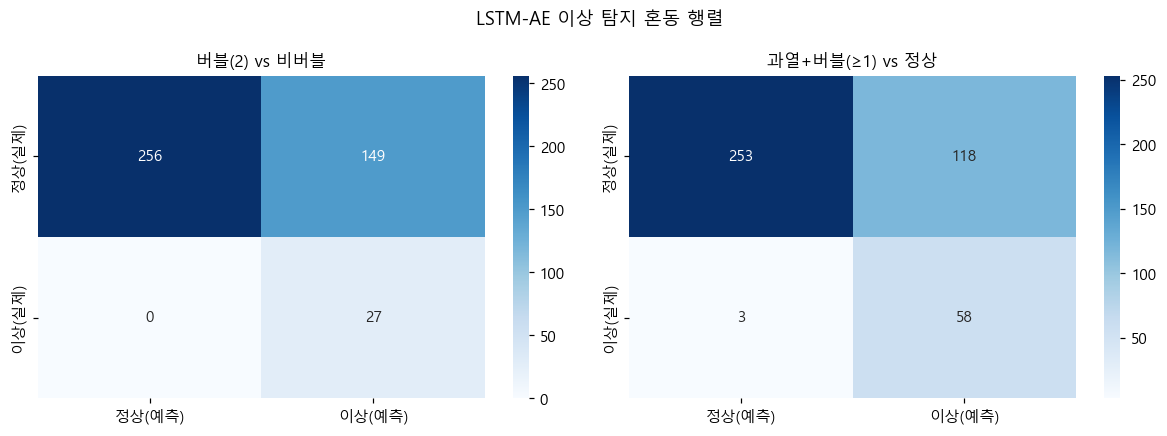

In [12]:
from sklearn.metrics import classification_report, roc_auc_score

eval_df = result_df[result_df['bubble_label'].notna()].copy()

# ── 버블(2) vs 정상/과열 이진 평가
y_true_b2 = (eval_df['bubble_label'] == 2).astype(int)
y_pred     = eval_df['anomaly']

print('=== 버블(2) 탐지 성능 ===')
print(classification_report(y_true_b2, y_pred,
                              target_names=['비버블', '버블'],
                              digits=3, zero_division=0))

# AUC-ROC
try:
    auc = roc_auc_score(y_true_b2, eval_df['recon_error'])
    print(f'AUC-ROC (재구성 오차 기반): {auc:.4f}')
except Exception as e:
    print(f'AUC 계산 오류: {e}')

# ── 버블+과열(≥1) vs 정상 이진 평가
y_true_b1 = (eval_df['bubble_label'] >= 1).astype(int)
print('\n=== 과열+버블(≥1) 탐지 성능 ===')
print(classification_report(y_true_b1, y_pred,
                              target_names=['정상', '과열/버블'],
                              digits=3, zero_division=0))

# ── 혼동 행렬 히트맵
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (y_true, title) in zip(axes, [
    (y_true_b2, '버블(2) vs 비버블'),
    (y_true_b1, '과열+버블(≥1) vs 정상'),
]):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['정상(예측)', '이상(예측)'],
                yticklabels=['정상(실제)', '이상(실제)'])
    ax.set_title(title, fontsize=11)
plt.suptitle('LSTM-AE 이상 탐지 혼동 행렬', fontsize=12)
plt.tight_layout()
plt.savefig('notebooks/fig_ae_04_confusion.png', bbox_inches='tight')
plt.show()

---
## 11. 재구성 오차 — 피처별 기여도 분석

피처별 재구성 오차 배율 (버블/정상):
                   피처  버블 평균 오차  정상 평균 오차  오차 배율(버블/정상)
                  PIR  0.088981  0.009937      8.954458
             매매_vol12  0.170752  0.019449      8.779258
           가계대출비중_yoy  0.233113  0.030358      7.678878
              미분양_yoy  0.063333  0.009931      6.377439
            base_rate  0.011961  0.002577      4.641314
              인허가_yoy  0.058918  0.013639      4.319753
             매매중위_YoY  0.109259  0.026278      4.157779
            차주당대출_yoy  0.021603  0.005303      4.073884
mortgage_rate_chg_yoy  0.018754  0.005055      3.710250
          rate_spread  0.014260  0.004279      3.332689
                 전세가율  0.029643  0.009440      3.140171
              소득대비전세율  0.025572  0.009138      2.798541
             매매중위_MoM  0.059191  0.021672      2.731183
       bsi_realestate  0.036321  0.014936      2.431778
           m2_yoy_pct  0.031059  0.016271      1.908889
          cpi_yoy_pct  0.008418  0.006529      1.289258


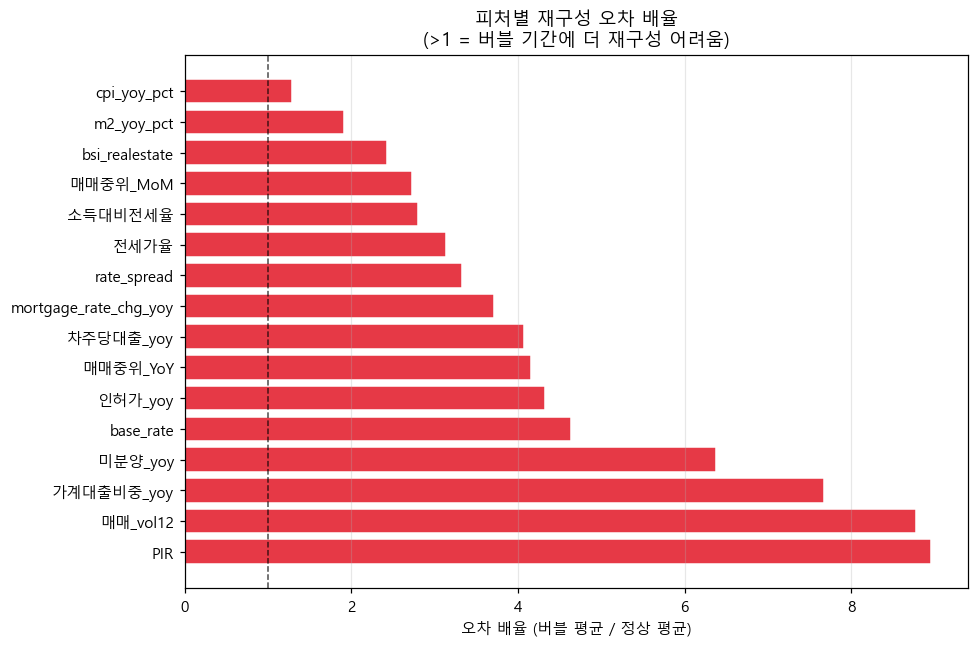

In [13]:
@torch.no_grad()
def get_feature_errors(model, seqs_np: np.ndarray, batch_size: int = 64):
    """
    피처별 평균 재구성 오차 반환.
    반환: (N, F) array — N 시퀀스 × F 피처
    """
    model.eval()
    ds     = DataLoader(SeqDataset(seqs_np), batch_size=batch_size)
    feat_e = []
    for x in ds:
        x = x.to(DEVICE)
        recon, _ = model(x)
        # (B, T, F) → mean over T → (B, F)
        mse_f = ((recon - x) ** 2).mean(dim=1)
        feat_e.append(mse_f.cpu().numpy())
    return np.vstack(feat_e)   # (N, F)

feat_err_all = get_feature_errors(final_model, all_seqs)

# 버블 vs 정상 — 피처별 평균 오차 비교
valid_idx    = ~np.isnan(all_label_list)
valid_labels = np.array(all_label_list)[valid_idx]
valid_feat   = feat_err_all[valid_idx]

bubble_mask = valid_labels == 2
normal_mask = valid_labels == 0

feat_err_bubble = valid_feat[bubble_mask].mean(axis=0)
feat_err_normal = valid_feat[normal_mask].mean(axis=0)
feat_ratio      = feat_err_bubble / (feat_err_normal + 1e-10)  # 버블/정상 오차 배율

feat_df = pd.DataFrame({
    '피처':       FEATURES,
    '버블 평균 오차': feat_err_bubble,
    '정상 평균 오차': feat_err_normal,
    '오차 배율(버블/정상)': feat_ratio,
}).sort_values('오차 배율(버블/정상)', ascending=False)

print('피처별 재구성 오차 배율 (버블/정상):')
print(feat_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#E63946' if v >= 1 else '#2A9D8F' for v in feat_df['오차 배율(버블/정상)']]
ax.barh(feat_df['피처'], feat_df['오차 배율(버블/정상)'],
        color=colors, edgecolor='white')
ax.axvline(1.0, color='black', ls='--', lw=1, alpha=0.7)
ax.set_xlabel('오차 배율 (버블 평균 / 정상 평균)')
ax.set_title('피처별 재구성 오차 배율\n(>1 = 버블 기간에 더 재구성 어려움)', fontsize=12)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('notebooks/fig_ae_05_feature_error.png', bbox_inches='tight')
plt.show()

---
## 12. 결과 저장 & 요약

In [14]:
# ── features_sido_monthly에 재구성 오차/이상 여부 병합 후 저장
# result_df 는 SEQ_LEN-1 이후 월부터 존재 → 초기 11개월은 NaN
save_df = df.merge(
    result_df[['ym', '시도', 'recon_error', 'anomaly']],
    on=['ym', '시도'], how='left'
)

out_path = 'data/processed/lstm_ae_scores.csv'
save_df.to_csv(out_path, index=False, encoding='utf-8-sig')
print(f'저장: {out_path}  ({save_df.shape})')

# ── 요약
print()
print('=' * 58)
print('  LSTM Autoencoder 이상 탐지 요약')
print('=' * 58)

print(f'\n[모델 파라미터]')
for k, v in best_params.items():
    print(f'  {k}: {v}')

print(f'\n[학습 결과]')
print(f'  학습용 정상 시퀀스: {len(train_seqs)}개 (seq_len={SEQ_LEN})')
print(f'  최종 val_loss:      {final_val:.5f}')
print(f'  이상 임계값:        {threshold:.5f} ({THRESHOLD_PCT}th pctile)')

print(f'\n[이상 탐지 결과]')
for sido in SIDO_LIST:
    sub_r = result_df[result_df['시도']==sido]
    sub_v = sub_r[sub_r['bubble_label'].notna()]
    b2_gt  = int((sub_v['bubble_label']==2).sum())
    a_pred = int(sub_r['anomaly'].sum())
    tp     = int(((sub_v['bubble_label']==2) & (sub_v['anomaly']==1)).sum())
    print(f'  {sido}: ground truth 버블={b2_gt}, 이상탐지={a_pred}, TP={tp}')

print(f'\n[저장 파일]')
print(f'  data/processed/lstm_ae_scores.csv')
print(f'  models/lstm_ae_best.pth')
print(f'  notebooks/fig_ae_01~05.png')
print('=' * 58)

저장: data/processed/lstm_ae_scores.csv  ((468, 45))

  LSTM Autoencoder 이상 탐지 요약

[모델 파라미터]
  hidden_size: 128
  latent_dim: 32
  num_layers: 1
  dropout: 0.1
  lr: 0.002847876440759923
  batch_size: 16

[학습 결과]
  학습용 정상 시퀀스: 263개 (seq_len=12)
  최종 val_loss:      0.00432
  이상 임계값:        0.00802 (95th pctile)

[이상 탐지 결과]
  서울: ground truth 버블=27, 이상탐지=100, TP=27
  경기: ground truth 버블=0, 이상탐지=45, TP=0
  인천: ground truth 버블=0, 이상탐지=34, TP=0

[저장 파일]
  data/processed/lstm_ae_scores.csv
  models/lstm_ae_best.pth
  notebooks/fig_ae_01~05.png
